In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Why does Apple lose strength across phases?

`brand_consistency.ipynb` found that Apple is the top brand in every unconstrained run
and goes negative in almost every constrained run. This notebook asks **why**, and leaves
with one surviving explanation.

Six conjectures, three of them about our own experiment design ("inner") and three about
the model itself ("outer"):

| # | conjecture | kind |
|---|---|---|
| **C1** | **Scale compression.** The named feature soaks up the logit scale; brand does not re-rank, it just shrinks toward 0. | inner |
| **C2** | **Regression to the mean.** Apple was singled out *because* it was top unconstrained. Any noisy re-measurement makes the top item look like it fell. | inner |
| **C3** | **Nuisance contamination.** Positional bias, prompt wording, or plain rerun noise is doing the work. | inner |
| **C4** | **Additivity is the wrong model.** One `brand_Apple` weight averages over 9 spec cells. Under a constraint the fit re-weights those cells, so the "same" number is not the same quantity. | inner |
| **C5** | **Any big perturbation disrupts brand.** Nothing special about Apple or about ram — a strong constraint just scrambles the small weights. | outer-ish |
| **C6** | **Brand credit is conditional on compliance.** Once the user states a spec, the premium brand keeps its premium only on items that match the spec, and is punished on items that miss it. | outer |

Everything is fitted with the same sum-to-zero Bradley-Terry used in
`brand_consistency.ipynb`, so the numbers are comparable to that notebook.

In [2]:
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D

BASE = ["data/laptops_robustness", "data/laptops_robustness_gemma"]
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
OTHER = ["ASUS", "Dell", "HP", "Lenovo"]
SC = ["13-inch", "14-inch", "16-inch"]
RM = ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SC, "ram": RM}
# Constraint ids come straight from config.json (2026-08-10 schema). CLAB is only for
# axis labels - nothing in the analysis parses these strings.
CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
SIZES = {"qwen": ["0.5", "7", "32", "72"], "gemma": ["1", "4", "12", "27"]}
# qwen-0.5B is noise on every measure (see brand_consistency.ipynb) - excluded from all stats.
REAL = [("qwen", s) for s in ["7", "32", "72"]] + [("gemma", s) for s in ["1", "4", "12", "27"]]

# Palette reused verbatim from brand_consistency.ipynb so the two notebooks read as one
# system. Re-checked with the dataviz validator (all-pairs, light surface): 5 brands PASS
# (worst CVD dE 13.0 protan, normal-vision 16.3); satisfy/violate pair PASS (dE 21.6).
BRAND_COLOR = dict(zip(BRANDS, ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
BRAND_MARKER = dict(zip(BRANDS, ["o", "s", "^", "D", "v"]))
SATISFY, VIOLATE = "#2a78d6", "#e34948"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
DIVERGING = LinearSegmentedColormap.from_list("bl_gy_rd", [VIOLATE, "#f0efec", SATISFY])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d1", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": "#e8e7e3", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
pd.set_option("display.width", 220)

In [3]:
def load():
    """Scores per run, plus the constraint DICT per run.

    Since the 2026-08-10 schema, config.json stores constraints as {feature: level} using
    the exact level strings from alternatives.py - the same strings that appear in
    scores.csv. That is what lets `satisfies` below work for any feature and any level
    with no hard-coded mapping.
    """
    R, C = {}, {}
    for b in BASE:
        for run in sorted(os.listdir(b)):
            cp = os.path.join(b, run, "config.json")
            if not os.path.isfile(cp):
                continue
            c = json.load(open(cp))
            key = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            R[key] = pd.read_csv(os.path.join(b, run, "scores.csv"))
            C[key] = c["constraints"]
    return R, C


def satisfies(constraints, **features):
    """Does an item with these feature levels meet the contract? Generic over features."""
    return all(features[f] == lvl for f, lvl in constraints.items())


def fit_bt(df, feats=("brand", "screen", "ram")):
    """Sum-to-zero feature Bradley-Terry with a positional-bias intercept.

    Same OLS trick as src.pref_models: regress (score_a - score_b) on a +1/-1 design.
    lstsq returns the minimum-norm solution, which for this design IS the sum-to-zero
    gauge (verified in progress.md); the explicit centering below just makes it visible.
    """
    y = (df.score_a - df.score_b).values
    cols, names = [np.ones(len(df))], ["gamma"]
    for f in feats:
        for l in LEVELS[f]:
            if l not in set(df["a_" + f]) | set(df["b_" + f]):
                continue
            cols.append((df["a_" + f].values == l).astype(float)
                        - (df["b_" + f].values == l).astype(float))
            names.append(f"{f}_{l}")
    X = np.column_stack(cols)
    w, *_ = np.linalg.lstsq(X, y, rcond=None)
    out = dict(zip(names, w))
    for f in feats:
        ks = [k for k in names if k.startswith(f + "_")]
        m = np.mean([out[k] for k in ks])
        for k in ks:
            out[k] -= m
    out["r2"] = 1 - (y - X @ w).var() / y.var()
    return out


def bvec(w):
    return np.array([w[f"brand_{b}"] for b in BRANDS])


def cell(df, screen, ram):
    """The 5 laptops that share this (screen, ram): they differ ONLY in brand."""
    return df[(df.a_screen == screen) & (df.b_screen == screen)
              & (df.a_ram == ram) & (df.b_ram == ram)]


RUNS, CONSTRAINTS = load()
W = {k: fit_bt(d) for k, d in RUNS.items()}
print(f"{len(RUNS)} runs loaded and fitted")

32 runs loaded and fitted


## 0. First, state the fact precisely

Two versions of the same claim: the Bradley-Terry weight, and a model-free win rate that
uses no fitting at all (restricted to pairs where the two laptops share screen and ram,
so brand is the only thing that differs).

In [4]:
rows = []
for fam, s in REAL:
    for c in CON:
        w = W[(fam, s, c)]
        bv = bvec(w)
        d = RUNS[(fam, s, c)]
        d = d[(d.a_screen == d.b_screen) & (d.a_ram == d.b_ram)]
        m = (d.score_a - d.score_b).values
        mar = np.concatenate([m[(d.a_brand == "Apple").values],
                              -m[(d.b_brand == "Apple").values]])
        rows.append(dict(fam=fam, size=s, con=CLAB[c], apple=bv[1],
                         rank=1 + (bv > bv[1]).sum(),
                         z=(bv[1] - bv.mean()) / bv.std(ddof=0),
                         win_pct=100 * float((mar > 0).mean()),
                         spread=bv.max() - bv.min()))
FACT = pd.DataFrame(rows)
order = [(f, s) for f, s in REAL]
cols = [CLAB[c] for c in CON]

for col, name in [("apple", "Apple's BT weight"), ("rank", "Apple's rank (1 = best of 5)"),
                  ("win_pct", "Apple win rate vs a same-spec rival (%, no model)")]:
    print(f"\n=== {name} ===")
    print(FACT.pivot_table(index=["fam", "size"], columns="con", values=col)
          .reindex(order)[cols].round(2 if col == "apple" else 1))


=== Apple's BT weight ===
con         none  14in   8GB  14in+8GB
fam   size                            
qwen  7     0.46 -0.77 -0.27     -0.70
      32    2.21  0.30 -0.74     -1.17
      72    1.95 -0.38 -1.73     -1.73
gemma 1     1.35  0.76 -0.50     -0.22
      4     1.73 -0.41 -0.92     -1.39
      12    1.28 -0.23 -1.80     -1.46
      27    2.74 -0.52 -1.36     -1.87

=== Apple's rank (1 = best of 5) ===
con         none  14in  8GB  14in+8GB
fam   size                           
qwen  7      1.0   5.0  5.0       5.0
      32     1.0   2.0  5.0       5.0
      72     1.0   5.0  5.0       5.0
gemma 1      1.0   2.0  4.0       3.0
      4      1.0   4.0  5.0       5.0
      12     1.0   3.0  5.0       5.0
      27     1.0   4.0  5.0       5.0

=== Apple win rate vs a same-spec rival (%, no model) ===
con         none  14in   8GB  14in+8GB
fam   size                            
qwen  7     50.3  48.9  50.6      41.1
      32    78.6  70.3  56.9      48.6
      72    72.5  58.9  43.

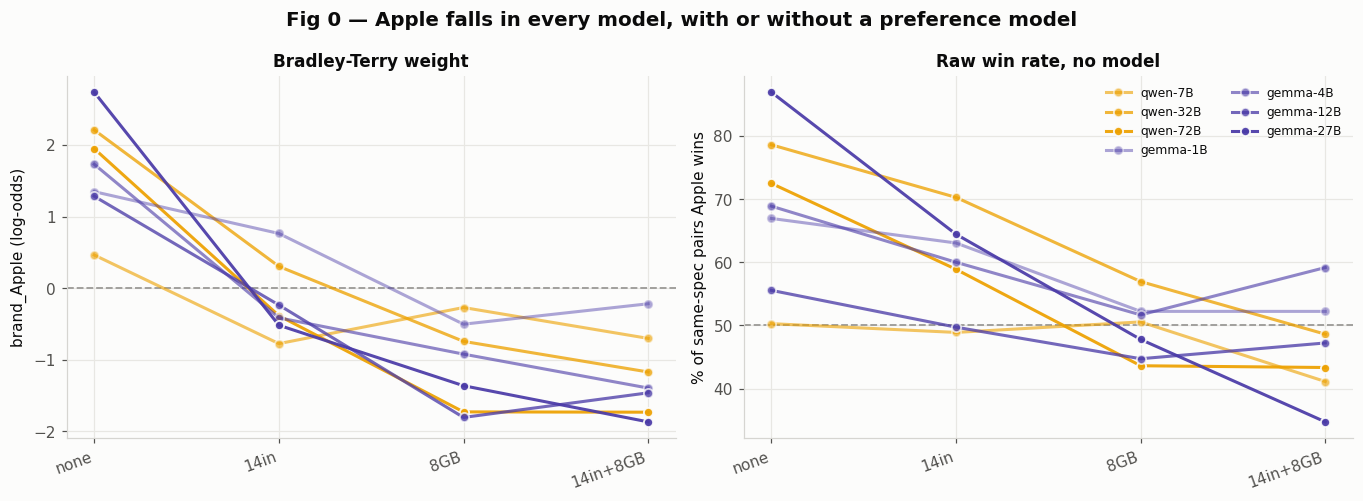

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
x = np.arange(4)
for ax, (col, ylab, ref, title) in zip(axes, [
        ("apple", "brand_Apple (log-odds)", 0.0, "Bradley-Terry weight"),
        ("win_pct", "% of same-spec pairs Apple wins", 50.0, "Raw win rate, no model")]):
    for fam, s in REAL:
        sub = FACT[(FACT.fam == fam) & (FACT["size"] == s)].set_index("con").reindex(cols)
        ax.plot(x, sub[col].values, marker="o", markersize=6, linewidth=2,
                color=BRAND_COLOR["Apple"] if fam == "qwen" else "#4a3aa7",
                alpha=0.45 + 0.16 * SIZES[fam].index(s),
                markeredgecolor=SURFACE, markeredgewidth=1.2,
                label=f"{fam}-{s}B", zorder=3)
    ax.axhline(ref, color="#9c9b98", linewidth=1.2, linestyle="--", zorder=1)
    ax.set_xticks(x, cols, rotation=20, ha="right")
    ax.set_ylabel(ylab)
    ax.set_title(title, fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8, frameon=False, ncol=2)
fig.suptitle("Fig 0 — Apple falls in every model, with or without a preference model",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Confirmed. gemma-27B goes from an 87% win rate to 35%; qwen-32B from 79% to 49%.
No fitting needed to see it, so nothing about Bradley-Terry is responsible.

Now the six conjectures.

## C1 — Scale compression? **No.**

If the constraint just shrank every brand weight toward zero, Apple would stay the *best*
brand, only by less. Rank and the within-block z-score are both scale-free, so they answer
this directly.

In [6]:
print("=== Apple's z-score inside the brand block (scale-free) ===")
print(FACT.pivot_table(index=["fam", "size"], columns="con", values="z")
      .reindex(order)[cols].round(2))
print("\nmean over the 7 models:")
print(FACT.groupby("con")[["z", "rank", "spread"]].mean().reindex(cols).round(2))

=== Apple's z-score inside the brand block (scale-free) ===
con         none  14in   8GB  14in+8GB
fam   size                            
qwen  7     1.36 -1.83 -1.48     -1.84
      32    1.68  0.58 -1.22     -1.63
      72    1.86 -1.23 -1.93     -1.95
gemma 1     1.31  0.73 -0.74     -0.19
      4     1.55 -0.69 -1.61     -1.64
      12    1.53 -0.63 -1.86     -1.87
      27    1.69 -0.89 -1.56     -1.83

mean over the 7 models:
             z  rank  spread
con                         
none      1.57  1.00    3.00
14in     -0.57  3.57    1.45
8GB      -1.49  4.86    1.87
14in+8GB -1.56  4.71    2.31


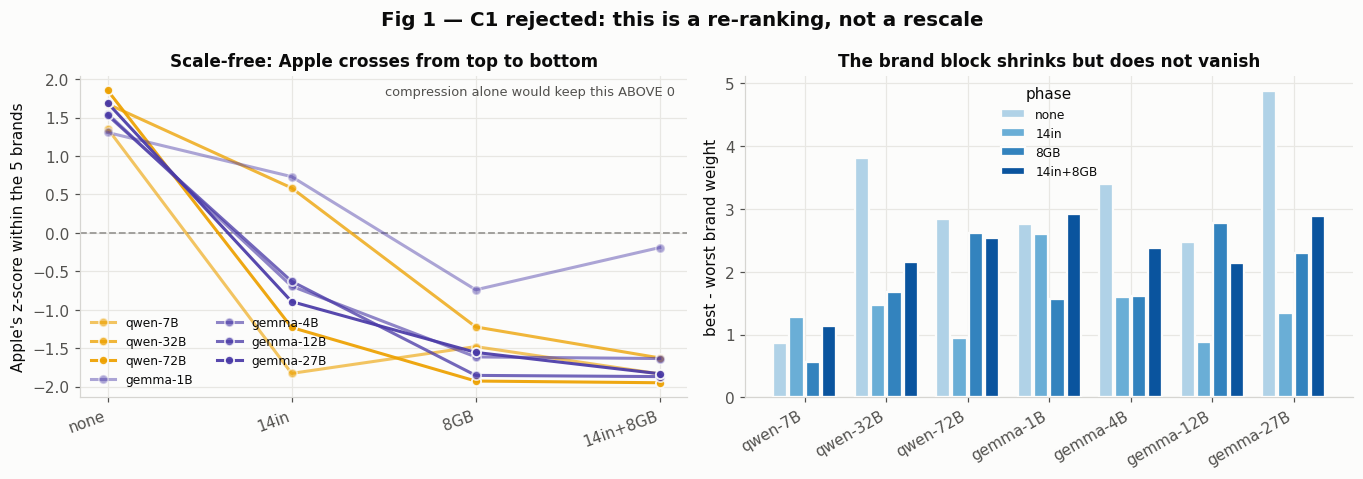

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for fam, s in REAL:
    sub = FACT[(FACT.fam == fam) & (FACT["size"] == s)].set_index("con").reindex(cols)
    axes[0].plot(x, sub["z"].values, marker="o", markersize=6, linewidth=2,
                 color=BRAND_COLOR["Apple"] if fam == "qwen" else "#4a3aa7",
                 alpha=0.45 + 0.16 * SIZES[fam].index(s), markeredgecolor=SURFACE,
                 markeredgewidth=1.2, label=f"{fam}-{s}B", zorder=3)
axes[0].axhline(0, color="#9c9b98", linewidth=1.2, linestyle="--")
axes[0].set_xticks(x, cols, rotation=20, ha="right")
axes[0].set_ylabel("Apple's z-score within the 5 brands")
axes[0].set_title("Scale-free: Apple crosses from top to bottom", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8, frameon=False, ncol=2, loc="lower left")
axes[0].text(0.98, 0.97, "compression alone would keep this ABOVE 0",
             transform=axes[0].transAxes, va="top", ha="right", fontsize=8.5, color=INK_MUTED)

# brand spread: is the block flattened?
sp = FACT.pivot_table(index=["fam", "size"], columns="con", values="spread").reindex(order)[cols]
w_ = 0.2
for i, c in enumerate(cols):
    axes[1].bar(np.arange(len(sp)) + (i - 1.5) * w_, sp[c].values, w_ * 0.88,
                color=plt.get_cmap("Blues")(0.32 + 0.18 * i),
                edgecolor=SURFACE, linewidth=1.5, label=c, zorder=3)
axes[1].set_xticks(np.arange(len(sp)), [f"{f}-{s}B" for f, s in sp.index], rotation=30, ha="right")
axes[1].set_ylabel("best - worst brand weight")
axes[1].set_title("The brand block shrinks but does not vanish", fontsize=11, fontweight="bold")
axes[1].legend(title="phase", frameon=False, fontsize=8)
fig.suptitle("Fig 1 — C1 rejected: this is a re-ranking, not a rescale",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Verdict: C1 rejected.** Apple's z-score goes from **+1.5 to −1.8** — it crosses zero and
lands near the theoretical minimum for 5 items. Its rank goes 1 → 5. A pure rescale cannot
change a rank. This also settles the open question in `progress.md`
("does the flip survive a per-run rescale?"): **yes**.

## C2 — Regression to the mean? **Not enough.**

Apple was picked out *because* it was the top brand with no constraint. If the constrained
brand weights were just a noisy redraw, the previously-top brand would fall by construction.

Two tests. First the pooled slope of the change on the baseline: `0` means perfectly stable,
`-1` means the new weights carry no memory of the old ones. Then the decisive one — **drop
Apple and ask whether the other four brands are stable.** Regression to the mean would
disorder them too.

In [8]:
rec = []
for fam, s in REAL:
    w0 = W[(fam, s, "none")]
    for c in CON[1:]:
        w1 = W[(fam, s, c)]
        for b in BRANDS:
            rec.append(dict(fam=fam, size=s, con=c, brand=b,
                            w0=w0[f"brand_{b}"], w1=w1[f"brand_{b}"]))
D = pd.DataFrame(rec)
D["dw"] = D.w1 - D.w0
sl, ic, r, p, se = st.linregress(D.w0, D.dw)
D["resid"] = D.dw - (ic + sl * D.w0)
print(f"pooled slope of (w_con - w_none) on w_none: {sl:+.2f}   "
      f"(0 = stable, -1 = memoryless redraw),  R2 = {r**2:.2f}")
rt = D.groupby("brand")["resid"].agg(["mean", "std", "count"])
rt["t"] = rt["mean"] / (rt["std"] / np.sqrt(rt["count"]))
rt["p"] = 2 * st.t.sf(rt["t"].abs(), rt["count"] - 1)
print("\nresidual from the regression-to-the-mean line (negative = falls MORE than predicted):")
print(rt.round(3))

pooled slope of (w_con - w_none) on w_none: -1.07   (0 = stable, -1 = memoryless redraw),  R2 = 0.73

residual from the regression-to-the-mean line (negative = falls MORE than predicted):
         mean    std  count      t      p
brand                                    
ASUS    0.668  0.306     21  9.999  0.000
Apple  -0.701  0.705     21 -4.557  0.000
Dell   -0.073  0.469     21 -0.715  0.483
HP     -0.452  0.533     21 -3.892  0.001
Lenovo  0.559  0.402     21  6.364  0.000


In [9]:
rows = []
for fam, s in REAL:
    w0 = W[(fam, s, "none")]
    a0 = bvec(w0)
    o0 = np.array([w0[f"brand_{b}"] for b in OTHER]); o0 = o0 - o0.mean()
    for c in CON[1:]:
        w1 = W[(fam, s, c)]
        a1 = bvec(w1)
        o1 = np.array([w1[f"brand_{b}"] for b in OTHER]); o1 = o1 - o1.mean()
        rows.append(dict(fam=fam, size=s, con=CLAB[c],
                         all5=np.corrcoef(a0, a1)[0, 1],
                         no_apple=np.corrcoef(o0, o1)[0, 1]))
K = pd.DataFrame(rows)
print("Correlation of the brand weights with the same model's unconstrained run:\n")
print(K.round(2).to_string(index=False))
print(f"\nmean   all 5 brands: {K.all5.mean():+.2f}   without Apple: {K.no_apple.mean():+.2f}")
print(f"median all 5 brands: {K.all5.median():+.2f}   without Apple: {K.no_apple.median():+.2f}")
print(f"share negative: all 5 = {100*(K.all5<0).mean():.0f}%   without Apple = {100*(K.no_apple<0).mean():.0f}%")
print("paired t-test:", st.ttest_rel(K.all5, K.no_apple))

Correlation of the brand weights with the same model's unconstrained run:

  fam size      con  all5  no_apple
 qwen    7     14in -0.39      0.77
 qwen    7      8GB -0.10      0.82
 qwen    7 14in+8GB -0.40      0.76
 qwen   32     14in  0.76      0.99
 qwen   32      8GB -0.09      0.98
 qwen   32 14in+8GB -0.37      0.98
 qwen   72     14in -0.30      0.91
 qwen   72      8GB -0.81      0.88
 qwen   72 14in+8GB -0.84      0.80
gemma    1     14in  0.94      0.99
gemma    1      8GB  0.46      1.00
gemma    1 14in+8GB  0.69      1.00
gemma    4     14in  0.30      0.96
gemma    4      8GB -0.26      0.99
gemma    4 14in+8GB -0.30      0.92
gemma   12     14in  0.32      0.93
gemma   12      8GB -0.48      0.95
gemma   12 14in+8GB -0.53      0.81
gemma   27     14in  0.09      0.98
gemma   27      8GB -0.32      1.00
gemma   27 14in+8GB -0.59      0.89

mean   all 5 brands: -0.11   without Apple: +0.92
median all 5 brands: -0.30   without Apple: +0.95
share negative: all 5 = 67%   wi

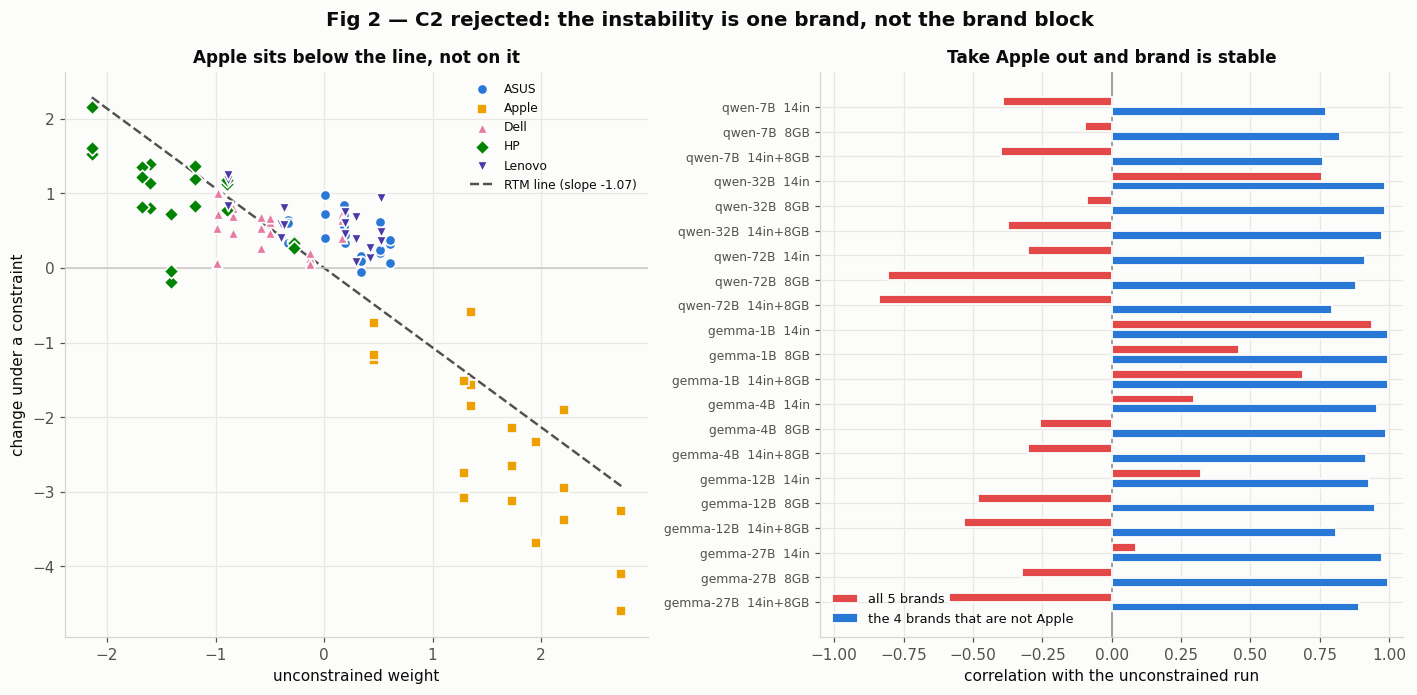

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.4))

ax = axes[0]
for b in BRANDS:
    sub = D[D.brand == b]
    ax.scatter(sub.w0, sub.dw, s=46, color=BRAND_COLOR[b], marker=BRAND_MARKER[b],
               edgecolor=SURFACE, linewidth=1.1, label=b, zorder=3)
xs = np.linspace(D.w0.min(), D.w0.max(), 10)
ax.plot(xs, ic + sl * xs, color=INK_MUTED, linewidth=1.6, linestyle="--", zorder=2,
        label=f"RTM line (slope {sl:+.2f})")
ax.axhline(0, color="#c9c8c4", linewidth=1)
ax.set_xlabel("unconstrained weight")
ax.set_ylabel("change under a constraint")
ax.set_title("Apple sits below the line, not on it", fontsize=11, fontweight="bold")
ax.legend(fontsize=8, frameon=False)

ax = axes[1]
lbl = [f"{f}-{s}B  {c}" for f, s, c in zip(K.fam, K["size"], K.con)]
yy = np.arange(len(K))
ax.barh(yy - 0.2, K.all5, 0.36, color=VIOLATE, edgecolor=SURFACE, linewidth=1.2,
        label="all 5 brands", zorder=3)
ax.barh(yy + 0.2, K.no_apple, 0.36, color=SATISFY, edgecolor=SURFACE, linewidth=1.2,
        label="the 4 brands that are not Apple", zorder=3)
ax.axvline(0, color="#9c9b98", linewidth=1.2)
ax.set_yticks(yy, lbl, fontsize=8)
ax.invert_yaxis()
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("correlation with the unconstrained run")
ax.set_title("Take Apple out and brand is stable", fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5, frameon=False, loc="lower left")
fig.suptitle("Fig 2 — C2 rejected: the instability is one brand, not the brand block",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Verdict: C2 rejected as the explanation.** The pooled slope is about `-1`, which on its
own looks like a memoryless redraw — but that number is *produced by Apple*. Once Apple is
removed, the remaining four brands correlate **+0.92 on average with the unconstrained run
and are never negative** (21/21 runs), against −0.11 and 67% negative for all five.

Apple is also a significant outlier from the regression-to-the-mean line itself
(residual −0.70, p < 0.001) while Dell sits on it.

> **This corrects the headline of `brand_consistency.ipynb`.** "Brand preference is not
> robust" is too broad. Four of the five brands hold their order across every constraint.
> One brand moves, and it moves a long way.

## C3 — Positional bias, prompt wording, or rerun noise? **No, all three.**

Three separate nuisances, three separate checks.

In [11]:
# --- C3a: positional bias. Symmetrizing kills gamma exactly; do the weights change? ---
def symmetrize(df):
    """margin_sym(A,B) = (m(A,B) - m(B,A)) / 2. gamma cancels by construction."""
    d = df.copy()
    a = list(zip(d.a_brand, d.a_screen, d.a_ram))
    b = list(zip(d.b_brand, d.b_screen, d.b_ram))
    m = dict(zip(zip(d.template_idx, a, b), (d.score_a - d.score_b).values))
    rev = np.array([m[(t, y, x)] for t, x, y in zip(d.template_idx, a, b)])
    d["score_a"] = ((d.score_a - d.score_b).values - rev) / 2.0
    d["score_b"] = 0.0
    return d

rows = []
for fam, s in REAL:
    for c in CON:
        w = fit_bt(symmetrize(RUNS[(fam, s, c)]))
        rows.append(dict(fam=fam, size=s, con=CLAB[c], apple_sym=w["brand_Apple"],
                         apple_orig=W[(fam, s, c)]["brand_Apple"], gamma=w["gamma"]))
S = pd.DataFrame(rows)
print("=== C3a: positional bias ===")
print(f"max |residual gamma| after symmetrizing: {S.gamma.abs().max():.2e}  (0 by construction)")
print(f"max |change in brand_Apple|:             {(S.apple_sym - S.apple_orig).abs().max():.2e}")
print("-> the design is balanced, so gamma is orthogonal to every feature contrast.")

=== C3a: positional bias ===
max |residual gamma| after symmetrizing: 2.86e-16  (0 by construction)
max |change in brand_Apple|:             7.33e-15
-> the design is balanced, so gamma is orthogonal to every feature contrast.


In [12]:
# --- C3b: prompt wording. 43 wordings of the same 14-inch-constrained question. ---
# PROVENANCE: data/laptops_robustness_50prompts/68337011 has no `constraints` field in its
# config (it predates that key). It is NOT unconstrained. Its templates 0-4 reproduce
# run 68337596 (qwen-7B, `14`) to within 0.25 log-odds per row - see the next cell - so it
# carries the "I prefer a 14-inch screen" preamble. Treat it as a 43-wording version of `14`.
d43 = pd.read_csv("data/laptops_robustness_50prompts/68337011/scores.csv")
per = []
for t, dd in d43.groupby("template_idx"):
    v = bvec(fit_bt(dd))
    per.append(dict(tmpl=t, **dict(zip(BRANDS, v)), apple_rank=1 + (v > v[1]).sum()))
P = pd.DataFrame(per)
print("=== C3b: 43 different prompt wordings, qwen-7B, 14-inch constraint ===")
print("Apple's rank across the 43 wordings:", P.apple_rank.value_counts().sort_index().to_dict())
print(f"brand_Apple: mean {P.Apple.mean():+.2f}, sd {P.Apple.std():.2f}, "
      f"range [{P.Apple.min():+.2f}, {P.Apple.max():+.2f}]")

# per-template stability across the main 5-template grid
rows = []
for fam, s in REAL:
    for c in CON:
        v = [fit_bt(dd)["brand_Apple"] for _, dd in RUNS[(fam, s, c)].groupby("template_idx")]
        rows.append(dict(fam=fam, size=s, con=CLAB[c], mean=np.mean(v), sd=np.std(v, ddof=1),
                         same_sign=bool(all(np.array(v) > 0) or all(np.array(v) < 0))))
TM = pd.DataFrame(rows)
print(f"\n5-template grid: all 5 templates agree on Apple's sign in "
      f"{100*TM.same_sign.mean():.0f}% of the 28 (model, phase) cells")
print("the disagreements:", TM[~TM.same_sign][["fam", "size", "con"]].to_dict("records"))

=== C3b: 43 different prompt wordings, qwen-7B, 14-inch constraint ===
Apple's rank across the 43 wordings: {5: 43}
brand_Apple: mean -0.88, sd 0.28, range [-1.63, -0.46]



5-template grid: all 5 templates agree on Apple's sign in 75% of the 28 (model, phase) cells
the disagreements: [{'fam': 'qwen', 'size': '72', 'con': '14in'}, {'fam': 'gemma', 'size': '1', 'con': 'none'}, {'fam': 'gemma', 'size': '1', 'con': '14in'}, {'fam': 'gemma', 'size': '1', 'con': '8GB'}, {'fam': 'gemma', 'size': '1', 'con': '14in+8GB'}, {'fam': 'gemma', 'size': '4', 'con': 'none'}, {'fam': 'gemma', 'size': '4', 'con': '14in'}]


In [13]:
# --- C3c: rerun noise. 68337011[tmpl 0-4] and 68337596 are the SAME 9900 prompts,
#     run twice on the cluster. Their difference is pure numerical / hardware noise. ---
key = ["template_idx", "a_brand", "a_screen", "a_ram", "b_brand", "b_screen", "b_ram"]
mm = d43[d43.template_idx < 5].merge(RUNS[("qwen", "7", "screen=14-inch")], on=key,
                                    suffixes=("_1", "_2"))
print("=== C3c: rerun noise floor ===")
print(f"matched rows: {len(mm)}")
print(f"per-row  max |score_a difference| = {np.abs(mm.score_a_1 - mm.score_a_2).max():.3f} log-odds")
w1, w2 = fit_bt(d43[d43.template_idx < 5]), W[("qwen", "7", "screen=14-inch")]
print("fitted brand weights from the two runs:")
for b in BRANDS:
    print(f"   {b:7s} {w1['brand_'+b]:+.3f}  vs  {w2['brand_'+b]:+.3f}"
          f"   diff {w1['brand_'+b]-w2['brand_'+b]:+.4f}")
print("-> bfloat16 jitter is visible row by row but averages out completely in the fit.")

=== C3c: rerun noise floor ===
matched rows: 9900
per-row  max |score_a difference| = 0.250 log-odds
fitted brand weights from the two runs:
   ASUS    +0.505  vs  +0.505   diff +0.0009
   Apple   -0.777  vs  -0.774   diff -0.0030
   Dell    +0.001  vs  -0.001   diff +0.0017
   HP      +0.085  vs  +0.085   diff +0.0001
   Lenovo  +0.185  vs  +0.185   diff +0.0003
-> bfloat16 jitter is visible row by row but averages out completely in the fit.


In [14]:
# --- honest error bars: cluster bootstrap over the 990 unordered item pairs ---
# 10 rows share every unordered pair (2 orders x 5 templates), so OLS SEs are ~3x too small
# (progress.md, 2026-08-09). Resample pairs, not rows.
rng = np.random.default_rng(0)

def boot_apple(df, B=400):
    y = (df.score_a - df.score_b).values
    cols_, names = [np.ones(len(df))], ["gamma"]
    for f in ("brand", "screen", "ram"):
        for l in LEVELS[f]:
            cols_.append((df["a_" + f].values == l).astype(float)
                         - (df["b_" + f].values == l).astype(float))
            names.append(f"{f}_{l}")
    X = np.column_stack(cols_)
    a = list(zip(df.a_brand, df.a_screen, df.a_ram))
    b = list(zip(df.b_brand, df.b_screen, df.b_ram))
    pid = pd.factorize(pd.Series([str(sorted([x, y_])) for x, y_ in zip(a, b)]))[0]
    G, k = pid.max() + 1, X.shape[1]
    XtX, Xty = np.zeros((G, k, k)), np.zeros((G, k))
    for g in range(G):
        m = pid == g
        XtX[g], Xty[g] = X[m].T @ X[m], X[m].T @ y[m]
    bi = [names.index(f"brand_{x}") for x in BRANDS]
    out = []
    for _ in range(B):
        sm = rng.integers(0, G, G)
        ww = np.linalg.pinv(XtX[sm].sum(0)) @ Xty[sm].sum(0)
        v = ww[bi] - ww[bi].mean()
        out.append(v[1])
    return np.percentile(out, [2.5, 97.5])

print("=== 95% cluster-bootstrap CI for brand_Apple (clustered by unordered pair) ===")
CI = []
for fam, s in [("qwen", "32"), ("qwen", "72"), ("gemma", "27")]:
    for c in CON:
        lo, hi = boot_apple(RUNS[(fam, s, c)])
        CI.append(dict(fam=fam, size=s, con=CLAB[c], est=W[(fam, s, c)]["brand_Apple"],
                       lo=lo, hi=hi))
        print(f"  {fam}-{s}B {CLAB[c]:9s} {CI[-1]['est']:+.2f}   [{lo:+.2f}, {hi:+.2f}]")
CI = pd.DataFrame(CI)

=== 95% cluster-bootstrap CI for brand_Apple (clustered by unordered pair) ===


  qwen-32B none      +2.21   [+1.55, +2.91]
  qwen-32B 14in      +0.30   [-0.24, +0.85]


  qwen-32B 8GB       -0.74   [-1.14, -0.40]
  qwen-32B 14in+8GB  -1.17   [-1.63, -0.75]


  qwen-72B none      +1.95   [+1.57, +2.35]
  qwen-72B 14in      -0.38   [-0.79, +0.09]


  qwen-72B 8GB       -1.73   [-1.87, -1.57]
  qwen-72B 14in+8GB  -1.73   [-2.02, -1.38]


  gemma-27B none      +2.74   [+2.09, +3.43]
  gemma-27B 14in      -0.52   [-1.21, +0.16]


  gemma-27B 8GB       -1.36   [-1.74, -0.96]
  gemma-27B 14in+8GB  -1.87   [-2.56, -1.16]


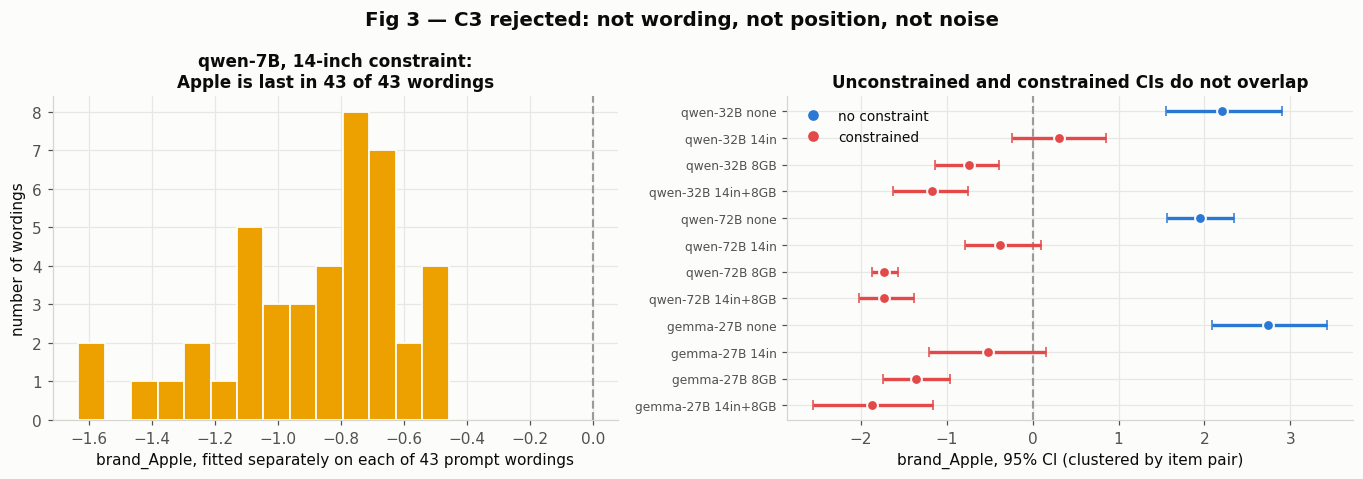

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
ax.hist(P.Apple, bins=14, color=BRAND_COLOR["Apple"], edgecolor=SURFACE, linewidth=1.2, zorder=3)
ax.axvline(0, color="#9c9b98", linewidth=1.4, linestyle="--")
ax.set_xlabel("brand_Apple, fitted separately on each of 43 prompt wordings")
ax.set_ylabel("number of wordings")
ax.set_title("qwen-7B, 14-inch constraint:\nApple is last in 43 of 43 wordings",
             fontsize=11, fontweight="bold")

ax = axes[1]
lbl = [f"{f}-{s}B {c}" for f, s, c in zip(CI.fam, CI["size"], CI.con)]
yy = np.arange(len(CI))
for is_none, colr in [(True, SATISFY), (False, VIOLATE)]:
    m = (CI.con == "none").values if is_none else (CI.con != "none").values
    ax.errorbar(CI.est[m], yy[m], xerr=[(CI.est - CI.lo)[m], (CI.hi - CI.est)[m]],
                fmt="none", ecolor=colr, elinewidth=2.2, capsize=3.5, zorder=3)
    ax.scatter(CI.est[m], yy[m], s=50, color=colr, edgecolor=SURFACE, linewidth=1.3, zorder=4)
ax.axvline(0, color="#9c9b98", linewidth=1.4, linestyle="--")
ax.set_yticks(yy, lbl, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("brand_Apple, 95% CI (clustered by item pair)")
ax.set_title("Unconstrained and constrained CIs do not overlap", fontsize=11, fontweight="bold")
ax.legend(handles=[Line2D([], [], marker="o", linestyle="", color=SATISFY, label="no constraint"),
                   Line2D([], [], marker="o", linestyle="", color=VIOLATE, label="constrained")],
          frameon=False, fontsize=9, loc="upper left")
fig.suptitle("Fig 3 — C3 rejected: not wording, not position, not noise",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Verdict: C3 rejected on all three counts.**

- **Position:** symmetrizing the margins removes `gamma` exactly (residual 3e-16) and changes
  `brand_Apple` by ~1e-15. The design is balanced, so the positional bias — large as it is —
  cannot leak into any feature weight.
- **Wording:** across 43 different phrasings of the same constrained question, Apple is last
  in **43 out of 43**.
- **Noise:** the same 9900 prompts run twice on the cluster differ by up to 0.25 log-odds per
  row but give brand weights that agree to **0.003**. The effect we are chasing is ~3.

The clustered bootstrap CIs also separate cleanly: gemma-27B goes from `+2.74 [+2.09, +3.43]`
to `-1.87 [-2.56, -1.16]`.

> **Data-hygiene note.** `data/laptops_robustness_50prompts/68337011` has **no `constraints`
> field** in its `config.json`, so `load_scores_by_run` will read it as unconstrained. It is
> not — its rows reproduce the `14` run. Anything filtering on `constraints` should skip that
> folder until the config is fixed.

## C4 — Is the additive model averaging over cells that Apple does not fill equally?

`brand_Apple` is one number covering all 9 `(screen, ram)` cells. If Apple's appeal depends
on the spec, that single number is a weighted average, and a constraint changes the weights.

So first: **does Apple's advantage depend on the spec, with no constraint in the prompt?**
Fit brand utilities inside each cell separately — 5 laptops that differ only in brand.

In [16]:
cells = []
for fam, s in REAL:
    for c in CON:
        for sc in SC:
            for rm in RM:
                v = bvec(fit_bt(cell(RUNS[(fam, s, c)], sc, rm), ("brand",)))
                con = CONSTRAINTS[(fam, s, c)]
                sat = satisfies(con, screen=sc, ram=rm) if con else None
                cells.append(dict(fam=fam, size=s, con=CLAB[c], screen=sc, ram=rm,
                                  apple=v[1], rank=1 + (v > v[1]).sum(),
                                  z=(v[1] - v.mean()) / v.std(ddof=0),
                                  spread=v.max() - v.min(), sat=sat))
E = pd.DataFrame(cells)

u = E[E.con == "none"]
print("=== Apple's within-cell weight, UNCONSTRAINED runs (mean over 7 models) ===")
print(u.pivot_table(index="ram", columns="screen", values="apple").reindex(RM)[SC].round(2))
print("\nmarginal by ram:   ", u.groupby("ram")["apple"].mean().reindex(RM).round(2).to_dict())
print("marginal by screen:", u.groupby("screen")["apple"].mean().reindex(SC).round(2).to_dict())
print(f"\nApple is the top brand in {int((u['rank']==1).sum())}/{len(u)} cells with no constraint.")

=== Apple's within-cell weight, UNCONSTRAINED runs (mean over 7 models) ===
screen  13-inch  14-inch  16-inch
ram                              
4GB        4.40     2.77     2.30
8GB        7.37     6.27     5.19
16GB       8.04     7.23     7.23

marginal by ram:    {'4GB': 3.16, '8GB': 6.28, '16GB': 7.5}
marginal by screen: {'13-inch': 6.6, '14-inch': 5.42, '16-inch': 4.91}

Apple is the top brand in 56/63 cells with no constraint.


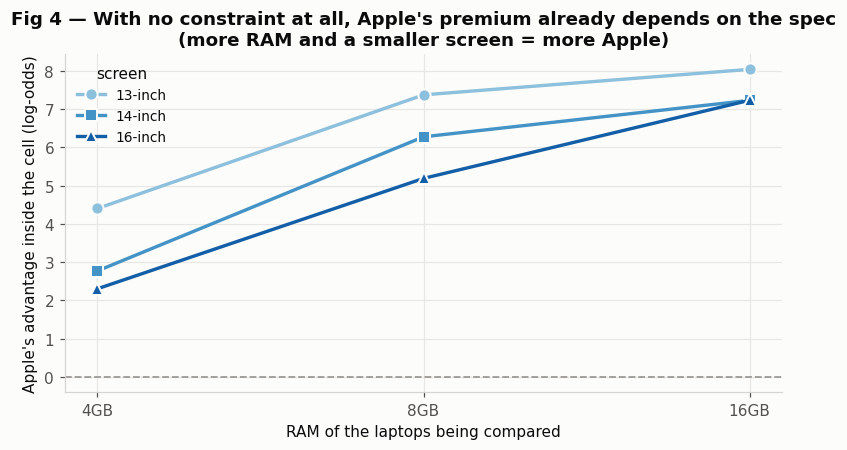

In [17]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for i, sc in enumerate(SC):
    vals = [u[(u.screen == sc) & (u.ram == rm)].apple.mean() for rm in RM]
    ax.plot(np.arange(3), vals, marker=BRAND_MARKER[BRANDS[i]], markersize=8, linewidth=2.2,
            color=plt.get_cmap("Blues")(0.42 + 0.2 * i), markeredgecolor=SURFACE,
            markeredgewidth=1.3, label=sc, zorder=3)
ax.axhline(0, color="#9c9b98", linewidth=1.2, linestyle="--")
ax.set_xticks(np.arange(3), RM)
ax.set_xlabel("RAM of the laptops being compared")
ax.set_ylabel("Apple's advantage inside the cell (log-odds)")
ax.set_title("Fig 4 — With no constraint at all, Apple's premium already depends on the spec\n"
             "(more RAM and a smaller screen = more Apple)", fontsize=12, fontweight="bold")
ax.legend(title="screen", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

So C4's premise is **true**: there is a real Apple x spec interaction *before any constraint
exists*. Apple's advantage runs **+3.2 at 4GB → +6.3 at 8GB → +7.5 at 16GB**, and
**+6.6 at 13-inch → +4.9 at 16-inch**. That is the model's product knowledge: a 4GB Apple and
a big-screen Apple are less Apple-like than a 16GB 13-inch one.

But a true premise is not a mechanism. If the collapse were only re-weighting of cells, it
would **disappear once we hold the cell fixed**. Test it: same 5 laptops, identical screen and
ram, only the preamble differs.

In [18]:
print("=== Apple's within-cell weight by phase (mean over the 7 models) ===")
print("Each number: 5 laptops with the SAME screen and ram, differing only in brand.\n")
for rm in RM:
    print(f"-- ram = {rm} --")
    print(E[E.ram == rm].pivot_table(index="screen", columns="con", values="apple")
          .reindex(SC)[cols].round(2))
    print()
print("pooled over all 9 cells:")
print(E.groupby("con")[["apple", "z", "spread"]].mean().reindex(cols).round(2))
print("\n% of cells where Apple is still the top brand:")
print(E.groupby("con")["rank"].apply(lambda v: 100 * (v == 1).mean()).reindex(cols).round(0).to_dict())

=== Apple's within-cell weight by phase (mean over the 7 models) ===
Each number: 5 laptops with the SAME screen and ram, differing only in brand.

-- ram = 4GB --
con      none  14in   8GB  14in+8GB
screen                             
13-inch  4.40  1.47 -2.87     -2.57
14-inch  2.77  1.15 -3.20     -3.38
16-inch  2.30 -0.22 -3.31     -1.99

-- ram = 8GB --
con      none  14in   8GB  14in+8GB
screen                             
13-inch  7.37  2.33  2.34     -1.53
14-inch  6.27  4.79  0.46      0.26
16-inch  5.19 -0.14 -0.47     -2.42

-- ram = 16GB --
con      none  14in   8GB  14in+8GB
screen                             
13-inch  8.04  2.99  0.71     -0.19
14-inch  7.23  5.87  0.10      0.07
16-inch  7.23  0.05 -0.11     -1.22

pooled over all 9 cells:
          apple     z  spread
con                          
none       5.64  1.49   10.45
14in       2.03  0.49    6.11
8GB       -0.70 -0.41    5.21
14in+8GB  -1.44 -0.77    5.21

% of cells where Apple is still the top brand:
{'none'

**Verdict: C4 rejected as the mechanism.** The premise holds — there really are Apple x spec
interactions — but the collapse survives with the cell held completely fixed. Averaged over
the 9 cells, Apple goes **+5.6 → +2.0 → −0.7 → −1.4**, and the share of cells where Apple is
still top goes **89% → 49% → 27% → 17%**.

The within-cell brand spread only falls from 10.5 to ~5.2, so the block is not flattened —
Apple is being *actively pushed down*, not muted.

## C5 — Does any large constraint scramble brand? **No — the two constraints differ.**

The `14` and the `8` constraints move their own feature by almost the same amount. If the
disruption were a generic side effect of a strong instruction, they should disrupt brand
equally.

In [19]:
rows = []
for fam, s in REAL:
    w0 = W[(fam, s, "none")]
    for c in ("screen=14-inch", "ram=8GB"):
        (f, l), = CONSTRAINTS[(fam, s, c)].items()
        w1 = W[(fam, s, c)]
        rows.append(dict(fam=fam, size=s, con=CLAB[c],
                         move=w1[f"{f}_{l}"] - w0[f"{f}_{l}"],
                         brand_corr=np.corrcoef(bvec(w0), bvec(w1))[0, 1],
                         apple_drop=w0["brand_Apple"] - w1["brand_Apple"]))
Dd = pd.DataFrame(rows)
print(Dd.round(2).to_string(index=False))
print("\nmean by constraint:")
print(Dd.groupby("con")[["move", "brand_corr", "apple_drop"]].mean().round(2))
print("\nhow much the constrained feature moves is nearly identical (8.4 vs 8.2 log-odds),")
print("but the effect on brand is not. Paired t-test on brand_corr, 14in vs 8GB:")
print(st.ttest_rel(Dd[Dd.con == "14in"].brand_corr.values, Dd[Dd.con == "8GB"].brand_corr.values))

  fam size  con  move  brand_corr  apple_drop
 qwen    7 14in  5.88       -0.39        1.24
 qwen    7  8GB  8.21       -0.10        0.73
 qwen   32 14in 13.46        0.76        1.91
 qwen   32  8GB  9.48       -0.09        2.95
 qwen   72 14in 11.39       -0.30        2.33
 qwen   72  8GB 11.96       -0.81        3.68
gemma    1 14in  0.18        0.94        0.58
gemma    1  8GB  1.83        0.46        1.85
gemma    4 14in  4.43        0.30        2.14
gemma    4  8GB  5.74       -0.26        2.65
gemma   12 14in  9.86        0.32        1.52
gemma   12  8GB  7.39       -0.48        3.09
gemma   27 14in 13.55        0.09        3.26
gemma   27  8GB 12.73       -0.32        4.10

mean by constraint:
      move  brand_corr  apple_drop
con                               
14in  8.39        0.24        1.85
8GB   8.19       -0.23        2.72

how much the constrained feature moves is nearly identical (8.4 vs 8.2 log-odds),
but the effect on brand is not. Paired t-test on brand_corr, 14in 

**Verdict: C5 rejected.** Same size of instruction-following (8.4 vs 8.2 log-odds), very
different consequence for brand: correlation with the unconstrained brand ordering is
**+0.24 under `14in` but −0.23 under `8GB`** (paired p = 0.016), and Apple's drop is
1.85 vs 2.72. Something about the constraint's *content* matters, not just its strength.

## C6 — Brand credit is conditional on compliance

Every rejected conjecture pointed the same way, and the within-cell table from C4 already
shows the pattern. Split the constrained cells by whether the cell **satisfies** the stated
contract or **violates** it.

In [20]:
sub = E[E.con != "none"].copy()
sub["sat"] = sub["sat"].astype(bool)
print("=== Apple inside cells that satisfy vs violate the contract ===")
print(sub.groupby(["con", "sat"])[["apple", "z", "spread"]].mean().round(2))
print("\npooled over the three constraints:")
print(sub.groupby("sat")[["apple", "z", "spread"]].agg(["mean", "count"]).round(2))
print(f"\nunconstrained reference: apple {E[E.con=='none'].apple.mean():+.2f}, "
      f"z {E[E.con=='none'].z.mean():+.2f}")
print("Welch t-test on Apple's z, satisfying vs violating cells:")
print(st.ttest_ind(sub[sub.sat].z.values, sub[~sub.sat].z.values, equal_var=False))

=== Apple inside cells that satisfy vs violate the contract ===
                apple     z  spread
con      sat                       
14in     False   1.08  0.18    4.84
         True    3.94  1.10    8.65
14in+8GB False  -1.65 -0.85    5.13
         True    0.26 -0.13    5.86
8GB      False  -1.45 -0.69    4.70
         True    0.78  0.16    6.22

pooled over the three constraints:
      apple           z       spread      
       mean count  mean count   mean count
sat                                       
False -0.77   140 -0.49   140   4.92   140
True   2.06    49  0.52    49   7.21    49

unconstrained reference: apple +5.64, z +1.49
Welch t-test on Apple's z, satisfying vs violating cells:
TtestResult(statistic=np.float64(5.143430706791791), pvalue=np.float64(1.273303391698093e-06), df=np.float64(104.15531605728262))


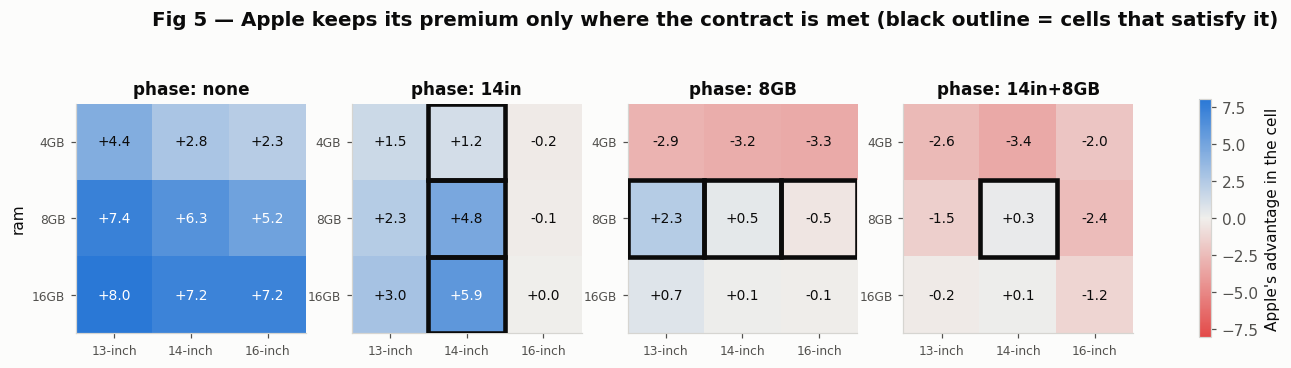

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.9))
grid = E.pivot_table(index=["con", "ram"], columns="screen", values="apple")
vmax = float(np.abs(grid.values).max())
for ax, c in zip(axes, cols):
    m = grid.loc[c].reindex(RM)[SC]
    im = ax.imshow(m.values, cmap=DIVERGING, norm=TwoSlopeNorm(0, -vmax, vmax))
    for i in range(3):
        for j in range(3):
            v = m.values[i, j]
            ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=9,
                    color="#ffffff" if abs(v) > 0.6 * vmax else INK)
    # outline the cells that satisfy this contract, straight from the config dict
    con = CONSTRAINTS[(REAL[0][0], REAL[0][1], {v: k for k, v in CLAB.items()}[c])]
    for i, rm in enumerate(RM):
        for j, sc in enumerate(SC):
            if con and satisfies(con, screen=sc, ram=rm):
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                           edgecolor=INK, linewidth=3, zorder=5))
    ax.set_xticks(range(3), SC, fontsize=8)
    ax.set_yticks(range(3), RM, fontsize=8)
    ax.set_title(f"phase: {c}", fontsize=11, fontweight="bold")
    ax.grid(False)
axes[0].set_ylabel("ram")
fig.colorbar(im, ax=axes, shrink=0.72, label="Apple's advantage in the cell")
fig.suptitle("Fig 5 — Apple keeps its premium only where the contract is met "
             "(black outline = cells that satisfy it)", fontsize=13, fontweight="bold")
plt.show()

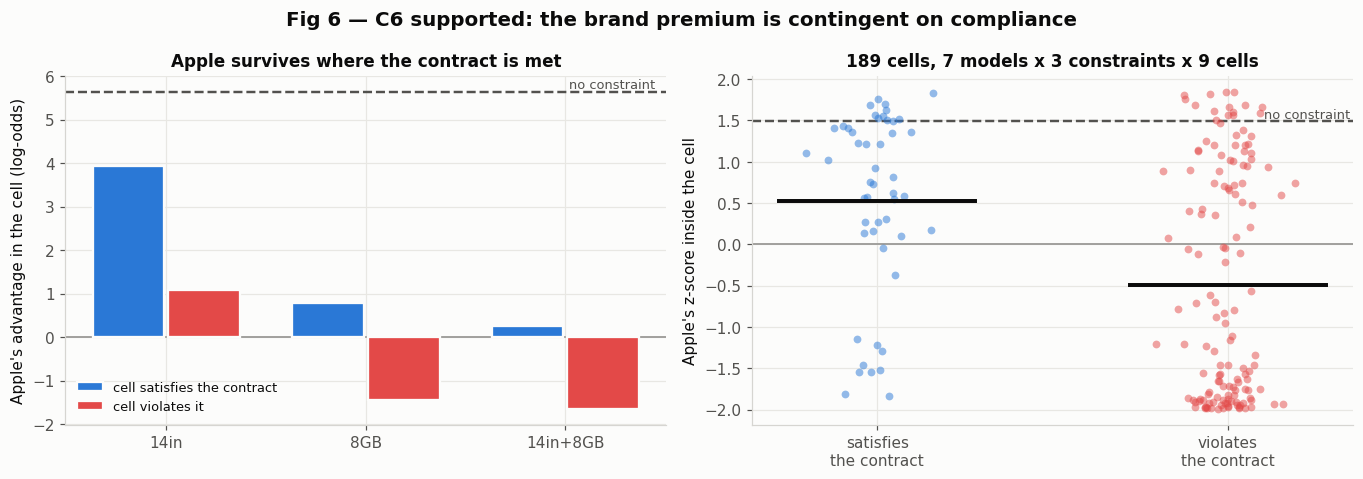

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
g = sub.groupby(["con", "sat"])["apple"].mean().unstack()
xx = np.arange(3)
ax.bar(xx - 0.19, g[True].reindex(cols[1:]).values, 0.36, color=SATISFY,
       edgecolor=SURFACE, linewidth=1.5, label="cell satisfies the contract", zorder=3)
ax.bar(xx + 0.19, g[False].reindex(cols[1:]).values, 0.36, color=VIOLATE,
       edgecolor=SURFACE, linewidth=1.5, label="cell violates it", zorder=3)
ax.axhline(E[E.con == "none"].apple.mean(), color=INK_MUTED, linewidth=1.6, linestyle="--",
           zorder=2)
ax.text(2.45, E[E.con == "none"].apple.mean(), "no constraint", va="bottom", ha="right",
        fontsize=8.5, color=INK_MUTED)
ax.axhline(0, color="#9c9b98", linewidth=1.2)
ax.set_xticks(xx, cols[1:])
ax.set_ylabel("Apple's advantage in the cell (log-odds)")
ax.set_title("Apple survives where the contract is met", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=8.5)

ax = axes[1]
for i, (lab, colr, dat) in enumerate([("satisfies", SATISFY, sub[sub.sat].z),
                                      ("violates", VIOLATE, sub[~sub.sat].z)]):
    j = np.random.default_rng(1).normal(i, 0.075, len(dat))
    ax.scatter(j, dat, s=26, color=colr, alpha=0.5, linewidths=0, zorder=3)
    ax.plot([i - 0.28, i + 0.28], [dat.mean()] * 2, color=INK, linewidth=2.6, zorder=5)
ax.axhline(E[E.con == "none"].z.mean(), color=INK_MUTED, linewidth=1.6, linestyle="--", zorder=2)
ax.text(1.35, E[E.con == "none"].z.mean(), "no constraint", va="bottom", ha="right",
        fontsize=8.5, color=INK_MUTED)
ax.axhline(0, color="#9c9b98", linewidth=1.2)
ax.set_xticks([0, 1], ["satisfies\nthe contract", "violates\nthe contract"])
ax.set_ylabel("Apple's z-score inside the cell")
ax.set_title("189 cells, 7 models x 3 constraints x 9 cells", fontsize=11, fontweight="bold")
fig.suptitle("Fig 6 — C6 supported: the brand premium is contingent on compliance",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Verdict: C6 is the surviving explanation.** Holding the spec cell completely fixed:

| | Apple's weight | Apple's z | brand spread |
|---|---|---|---|
| no constraint | **+5.64** | +1.49 | 10.5 |
| constrained, cell **satisfies** the contract | **+2.06** | +0.52 | 7.2 |
| constrained, cell **violates** it | **−0.77** | −0.49 | 4.9 |

Welch p = 1.3e-6 on the z-scores. The sharpest single case is the double constraint
`14in+8GB`: the only cell where Apple is still positive is 14-inch/8GB (+0.26) — the exact
contract match — and every other cell is negative.

**In words:** once the user states a specification, the model stops treating "Apple" as a
reason to prefer a laptop *unless that laptop meets the spec*. A non-compliant Apple is
penalised harder than a non-compliant Dell. The brand premium is not deleted; it becomes
**conditional on compliance**.

## An outer reason we can only half-test

C6 describes *what* happens. *Why* Apple is the brand this happens to has a plausible
outside-the-experiment answer: Apple laptops are sold as fixed configurations, and a
low-RAM Apple is a widely-discussed bad buy. The model may have learned that a buyer who
states a spec is not an Apple buyer.

Two pieces of support already in the data:

1. Apple's premium **already scales with RAM before any constraint exists** (+3.2 at 4GB →
   +7.5 at 16GB, Fig 4). That is product knowledge, not a contract effect.
2. The **RAM** constraint disrupts brand significantly more than the **screen** constraint,
   at equal instruction strength (C5).

What we cannot do with the current data: separate *"a spec was stated"* from *"a modest spec
was stated"*. Every constraint we have ever run asks for a mid or low level (14-inch of
13/14/16; 8GB of 4/8/16). The discriminating run already exists as an unused alias.

In [23]:
# The 2x2 of single constraints as it stands today. Constraint ids are now unambiguous -
# "screen=16-inch" and "ram=16GB" would both have been called "16" under the old scheme.
from scripts.data_collection import constraints_text, parse_constraints

have = sorted({k[2] for k in RUNS})
print("collected:", have, "\n")
for spec in ["screen=14-inch", "screen=16-inch", "ram=8GB", "ram=16GB"]:
    mark = "have" if spec in have else "MISSING"
    print(f"  {mark:8s} {spec:16s} {constraints_text(parse_constraints(spec))!r}")

/home/lotanamit/miniconda3/envs/whatdo-llms-want/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


collected: ['none', 'ram=8GB', 'ram=8GB+screen=14-inch', 'screen=14-inch'] 

  have     screen=14-inch   'I prefer a 14-inch screen.'
  MISSING  screen=16-inch   'I prefer a 16-inch screen.'
  have     ram=8GB          'I prefer 8 GB ram.'
  MISSING  ram=16GB         'I prefer 16 GB ram.'


## Summary

**The fact holds.** Apple goes from rank 1/5 in every unconstrained run to rank 4-5 under a
ram constraint, in both model families, at every size above the noise floor. It is visible
in a raw win rate with no model fitted (87% → 35% for gemma-27B), and the clustered
bootstrap CIs do not overlap.

| conjecture | verdict | the number that decides it |
|---|---|---|
| C1 scale compression | **rejected** | Apple's scale-free z goes +1.5 → −1.8; rank 1 → 5 |
| C2 regression to the mean | **rejected** | drop Apple and the other 4 brands correlate **+0.92** with baseline, never negative |
| C3 position / wording / noise | **rejected** | gamma cancels exactly; last in **43/43** wordings; rerun noise 0.003 |
| C4 additivity misspecification | premise **true**, not the mechanism | Apple x ram interaction is real, but the collapse survives inside a fixed cell |
| C5 any strong constraint | **rejected** | equal instruction strength (8.4 vs 8.2), opposite brand effect (+0.24 vs −0.23, p = 0.016) |
| **C6 brand credit is conditional on compliance** | **supported** | satisfying cells +2.06, violating cells −0.77, p = 1.3e-6 |

**Two corrections to earlier notes.**

1. `brand_consistency.ipynb` concluded "brand preference is not robust". Too broad — four of
   the five brands hold their order under every constraint (r = +0.92). The whole effect is
   one brand.
2. `data/laptops_robustness_50prompts/68337011` is labelled with no constraint but is
   actually the `14` condition; its config predates the `constraints` key.

**Also worth knowing (not the cause, but a caveat on the whole method).**

In [24]:
rows = []
for k, d in RUNS.items():
    for t, dd in d.groupby("template_idx"):
        ca, cb = dd.score_a.max(), dd.score_b.max()
        rows.append(dict(fam=k[0], size=k[1], con=CLAB[k[2]],
                         either=float(((dd.score_a > ca - .05) | (dd.score_b > cb - .05)).mean())))
SAT = pd.DataFrame(rows)
print("=== how often is the winning label's log-probability at its ceiling? ===")
print("score = logprob(label) - logprob(label | 'Answer: '), so it is capped at -logprob(base).")
print("At the cap the model puts ~100% of its mass on one option.\n")
print((100 * SAT.pivot_table(index=["fam", "size"], columns="con", values="either")
       .reindex([(f, s) for f in SIZES for s in SIZES[f]])[cols]).round(0))

=== how often is the winning label's log-probability at its ceiling? ===
score = logprob(label) - logprob(label | 'Answer: '), so it is capped at -logprob(base).
At the cap the model puts ~100% of its mass on one option.

con         none  14in   8GB  14in+8GB
fam   size                            
qwen  0.5    5.0   6.0   5.0       4.0
      7     91.0  89.0  77.0      90.0
      32    97.0  92.0  88.0      89.0
      72    95.0  89.0  81.0      86.0
gemma 1     94.0  96.0  96.0      94.0
      4     98.0  98.0  99.0      99.0
      12    99.0  96.0  96.0      95.0
      27    99.0  98.0  98.0      97.0


In **88-99%** of all comparisons one of the two labels is already at its ceiling — the model
is effectively certain. The margin we regress on is therefore carried almost entirely by the
*loser's* tail log-probability. This is equally true with and without a constraint, so it is
not what produces the Apple effect, but it does mean our "log-odds" are not calibrated
log-odds. (qwen-0.5B is the only model below 6% saturation — and the only one with no
measurable preference at all.)

## What to run next

1. **`16_16` — the premium contract.** Already in `CONSTRAINT_ALIASES`, never collected.
   8 models x 1 constraint. This is the one experiment that separates the two live readings
   of C6: does *any* stated spec strip Apple's premium from non-compliant items, or only a
   modest spec? If Apple survives `16_16`, the story is "spec-shopper framing"; if Apple
   still collapses, it is "any stated contract".
2. **A genuinely empty prompt.** Every run we have — including the ones we call
   "unconstrained" — carries the line *"I am looking to buy a laptop."* We have never
   measured the brand preference without it, so we cannot say whether the Apple premium is
   the model's own or is created by the shopping frame.
3. **A constraint on a dimension that is not in the item set** (e.g. *"I prefer a lightweight
   laptop"*). Separates "any extra sentence" from "a spec that the items can meet or miss".